# Routing Agent Example

This notebook shows why LangGraph is useful.

The agent can choose between different paths:

- refund
- cook_food
- ask_question
- call_tool
- end_chat

## Easy Restaurant Example

Imagine a restaurant help desk.

Different customer messages need different actions:

| Customer says | Agent route |
| --- | --- |
| I want biryani | cook_food |
| I want my money back | refund |
| What is on the menu? | ask_question |
| Check my order status | call_tool |
| Bye | end_chat |

LangGraph lets us write these routes clearly.

In [1]:
from typing import Annotated, TypedDict
import gradio as gr
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

## Define State

State is the information bag.

It carries the user message, selected route, and final response.

In [3]:
class RoutingState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    user_message: str
    route: str
    final_response: str

## Decision Node

This node reads the customer message and decides which route to follow.

For learning, we use simple keyword rules.

Later, this decision can be made by an LLM.

In [4]:
def decide_route(state: RoutingState) -> RoutingState:
    user_message = state["user_message"].lower()

    if "refund" in user_message or "money back" in user_message:
        route = "refund"
    elif "status" in user_message or "track" in user_message or "check" in user_message:
        route = "call_tool"
    elif "?" in user_message or "available" in user_message or "menu" in user_message:
        route = "ask_question"
    elif "bye" in user_message or "exit" in user_message or "stop" in user_message:
        route = "end_chat"
    else:
        route = "cook_food"

    print("Selected route:", route)
    return {"route": route, "messages": [f"Router selected: {route}"]}

## Action Nodes

Each function below is one possible path.

Think of each node as a different counter in the restaurant.

In [5]:
def refund_node(state: RoutingState) -> RoutingState:
    response = "I understand. I will start your refund request. Please share your order number."
    return {"final_response": response, "messages": [response]}


def cook_food_node(state: RoutingState) -> RoutingState:
    response = "Your order is accepted. The kitchen will start preparing your food now."
    return {"final_response": response, "messages": [response]}


def ask_question_node(state: RoutingState) -> RoutingState:
    response = "Sure. Please tell me which item you want, for example biryani, burger, or pizza."
    return {"final_response": response, "messages": [response]}


def call_tool_node(state: RoutingState) -> RoutingState:
    # Fake tool for learning. Later this could call a real database or API.
    fake_order_status = "Your order is being prepared and will be ready in 15 minutes."
    return {"final_response": fake_order_status, "messages": [fake_order_status]}


def end_chat_node(state: RoutingState) -> RoutingState:
    response = "Thank you. Chat ended. Have a nice day!"
    return {"final_response": response, "messages": [response]}

## Routing Function

This function tells LangGraph which edge to follow after the decision node.

In [6]:
def route_after_decision(state: RoutingState) -> str:
    return state["route"]

## Build Conditional Graph

This is the important LangGraph part.

`add_conditional_edges` means: choose the next node based on the route.

In [7]:
routing_builder = StateGraph(RoutingState)

routing_builder.add_node("decide_route", decide_route)
routing_builder.add_node("refund", refund_node)
routing_builder.add_node("cook_food", cook_food_node)
routing_builder.add_node("ask_question", ask_question_node)
routing_builder.add_node("call_tool", call_tool_node)
routing_builder.add_node("end_chat", end_chat_node)

routing_builder.add_edge(START, "decide_route")

routing_builder.add_conditional_edges(
    "decide_route",
    route_after_decision,
    {
        "refund": "refund",
        "cook_food": "cook_food",
        "ask_question": "ask_question",
        "call_tool": "call_tool",
        "end_chat": "end_chat",
    }
)

routing_builder.add_edge("refund", END)
routing_builder.add_edge("cook_food", END)
routing_builder.add_edge("ask_question", END)
routing_builder.add_edge("call_tool", END)
routing_builder.add_edge("end_chat", END)

routing_graph = routing_builder.compile()

## Display Graph

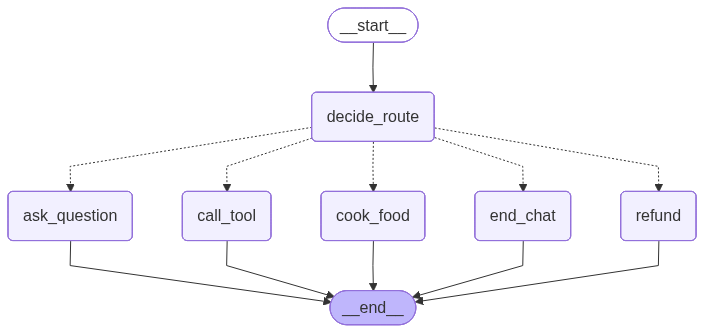

In [8]:
routing_graph

## Test All Routes

Run this cell to see all five paths.

In [9]:
examples = [
    "I want chicken biryani",
    "I want a refund",
    "What is available on the menu?",
    "Please check my order status",
    "bye"
]

for text in examples:
    print("User:", text)
    output = routing_graph.invoke({"user_message": text, "messages": []})
    print("Agent:", output["final_response"])
    print("-" * 50)

User: I want chicken biryani
Selected route: cook_food
Agent: Your order is accepted. The kitchen will start preparing your food now.
--------------------------------------------------
User: I want a refund
Selected route: refund
Agent: I understand. I will start your refund request. Please share your order number.
--------------------------------------------------
User: What is available on the menu?
Selected route: ask_question
Agent: Sure. Please tell me which item you want, for example biryani, burger, or pizza.
--------------------------------------------------
User: Please check my order status
Selected route: call_tool
Agent: Your order is being prepared and will be ready in 15 minutes.
--------------------------------------------------
User: bye
Selected route: end_chat
Agent: Thank you. Chat ended. Have a nice day!
--------------------------------------------------


/Users/maria/Documents/Agentic-AI/venv/lib/python3.12/site-packages/langsmith/client.py:653: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37b8-e381-7592-8309-2a02bd4c0abc,id=019f37b8-e381-7592-8309-2a02bd4c0abc; trace=019f37b8-e381-7592-8309-2a02bd4c0abc,id=019f37b8-e3cf-7fb1-bb4a-cbaad493579a; trace=019f37b8-e381-7592-8309-2a02bd4c0abc,id=019f37b8-e3cf-7fb1-bb4a-cbb92e0abac9; trace=019f37b8-e381-7592-8309-2a02bd4c0abc,id=019f37b8-e3d0-75f1-a171-fde0391e5fa1; trace=019f37b8-e3d3-7ed1-a0d9-bfce329c816e,id=019f37b8-e3d3-7ed1-a0d9-bfce329c816e; trace=019f37b8-e3d3-7ed1-a0d9-bfce329c816e,id=019f37b8-e3d4-7212-9728-726793f5ad0b; trace=019f37b8-e3d3-7ed1-a0d9-bfce329c816e,id=019f37b8-e3d4-7212-9728-7274d82e1c92; trace=019f37b8-e3d3-7ed1-a0d9-bfce329c816e,id=019f37b8-e3d4-7212-9728-728b321e3bde; trace=019f37b8-e3d5-73c2-851a-6bffa52d9efe,id=019f37b8-e

## Gradio App

This app lets you type your own message and see which route the agent uses.

In [10]:
def routing_agent_app(user_message: str) -> str:
    if not user_message.strip():
        return "Please type a message."

    output = routing_graph.invoke({
        "user_message": user_message,
        "messages": []
    })

    return output["final_response"]

In [ ]:
routing_demo = gr.Interface(
    fn=routing_agent_app,
    inputs=gr.Textbox(label="Customer Message", placeholder="Try: I want a refund"),
    outputs=gr.Textbox(label="Agent Reply"),
    title="Restaurant Routing Agent",
    description="LangGraph chooses between refund, cook_food, ask_question, call_tool, and end_chat."
)

routing_demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


/Users/maria/Documents/Agentic-AI/venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Selected route: cook_food


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a33-7a42-9f42-d4550ac01f3b; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a38-7921-83dd-1f17c7278bde; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a38-7921-83dd-1f17c7278bde; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a33-7a42-9f42-d4550ac01f3b; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a3a-7e00-b2f2-067e201835e0; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a3a-7e00-b2f2-067e201835e0; trace=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73,id=019f37b9-5a2d-7fa0-95e8-7726e1ec5d73
/Users/maria/Documents/Agentic-AI/venv/lib/pyt

Selected route: cook_food


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a4-7923-8cac-2ef085742590; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a8-71e2-87b2-7cfeae8990d3; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a9-7063-a89f-28ae6eae9aa4; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a9-7063-a89f-28ae6eae9aa4; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a8-71e2-87b2-7cfeae8990d3; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4c7-7dc2-b73a-3e06d39a3c7e; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4c7-7dc2-b73a-3e06d39a3c7e; trace=019f37b9-a4a4-7923-8cac-2ef085742590,id=019f37b9-a4a4-7923-8cac-2ef085742590
/Users/maria/Documents/Agentic-AI/venv/lib/pyt

Selected route: refund


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d5fe-7be0-bbd2-2d37a8cad190; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d606-72d3-a284-f6e704e5a89f; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d60a-7140-8857-98810c0cd5d1; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d60a-7140-8857-98810c0cd5d1; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d606-72d3-a284-f6e704e5a89f; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d60c-7560-a28a-4904dd7f401a; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d60c-7560-a28a-4904dd7f401a; trace=019f37b9-d5fe-7be0-bbd2-2d37a8cad190,id=019f37b9-d5fe-7be0-bbd2-2d37a8cad190
